In [18]:
# Import and Path
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ML_PATH = "results/metrics/ml_baselines_metrics.csv"
TR_PATH = "results/metrics/transformers_metrics.csv"

assert os.path.exists(ML_PATH), f"Missing: {ML_PATH}"
assert os.path.exists(TR_PATH), f"Missing: {TR_PATH}"

os.makedirs("results/metrics", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)

print("OK: paths and output folders ready.")

OK: paths and output folders ready.


In [19]:
# Load CSVs
ml = pd.read_csv(ML_PATH)
tr = pd.read_csv(TR_PATH)

print("ML shape:", ml.shape)
print("Transformers shape:", tr.shape)

display(ml.head())
display(tr.head())

ML shape: (8, 5)
Transformers shape: (8, 7)


,Experiment,Accuracy,Precision,Recall,F1
0,LR (ISOT→ISOT),0.989458,0.986977,0.990971,0.988970
1,LR (ISOT→LIAR),0.371744,0.666667,0.024814,0.047847
2,LR (LIAR→ISOT),0.479733,0.477724,0.974782,0.641204
3,LR (LIAR→LIAR),0.640884,0.655723,0.916873,0.764615
4,SVM (ISOT→ISOT),0.994803,0.995632,0.993462,0.994546


,Model,TrainingDomain,TestType,accuracy,precision,recall,f1
0,bert-base-uncased,TRAIN_LIAR,In-domain,0.636148,0.636364,0.998759,0.777402
1,bert-base-uncased,TRAIN_LIAR,Cross-domain,0.501667,0.500835,1.000000,0.667408
2,roberta-base,TRAIN_LIAR,In-domain,0.636938,0.636867,0.998759,0.777778
3,roberta-base,TRAIN_LIAR,Cross-domain,0.500000,0.500000,1.000000,0.666667
4,bert-base-uncased,TRAIN_ISOT,In-domain,1.000000,1.000000,1.000000,1.000000


In [20]:
# Normalise ML table into a common schema
def parse_ml_experiment(exp: str):
    # exp examples: "LR (LIAR→LIAR)", "SVM (ISOT→LIAR)"
    m = re.match(r"^(LR|SVM)\s+\((LIAR|ISOT)→(LIAR|ISOT)\)$", exp.strip())
    if not m:
        raise ValueError(f"Unexpected ML Experiment format: {exp}")
    model, train_d, test_d = m.group(1), m.group(2), m.group(3)
    test_type = "In-domain" if train_d == test_d else "Cross-domain"
    return model, train_d, test_d, test_type

ml_norm = ml.copy()
parsed = ml_norm["Experiment"].apply(parse_ml_experiment)
ml_norm["Model"] = parsed.apply(lambda x: x[0])
ml_norm["TrainDomain"] = parsed.apply(lambda x: x[1])
ml_norm["TestDomain"] = parsed.apply(lambda x: x[2])
ml_norm["TestType"] = parsed.apply(lambda x: x[3])

# keep metrics columns
ml_norm = ml_norm[["Model","TrainDomain","TestDomain","TestType","Accuracy","Precision","Recall","F1"]]
ml_norm["Family"] = "ML"

display(ml_norm.sort_values(["Model","TrainDomain","TestDomain"]).head(10))

,Model,TrainDomain,TestDomain,TestType,Accuracy,Precision,Recall,F1,Family
0,LR,ISOT,ISOT,In-domain,0.989458,0.986977,0.990971,0.988970,ML
1,LR,ISOT,LIAR,Cross-domain,0.371744,0.666667,0.024814,0.047847,ML
2,LR,LIAR,ISOT,Cross-domain,0.479733,0.477724,0.974782,0.641204,ML
3,LR,LIAR,LIAR,In-domain,0.640884,0.655723,0.916873,0.764615,ML
4,SVM,ISOT,ISOT,In-domain,0.994803,0.995632,0.993462,0.994546,ML
5,SVM,ISOT,LIAR,Cross-domain,0.370166,0.642857,0.022333,0.043165,ML
6,SVM,LIAR,ISOT,Cross-domain,0.494135,0.483572,0.893524,0.627528,ML
7,SVM,LIAR,LIAR,In-domain,0.604578,0.664865,0.763027,0.710572,ML


In [21]:
# Normalise Transformer table into the same schema
tr_norm = tr.copy()

# rename to match
tr_norm = tr_norm.rename(columns={
    "TrainingDomain": "TrainDomain"
})

# map TrainDomain values
tr_norm["TrainDomain"] = tr_norm["TrainDomain"].replace({
    "TRAIN_LIAR": "LIAR",
    "TRAIN_ISOT": "ISOT"
})

# infer TestDomain from TestType + TrainDomain
def infer_test_domain(train_domain, test_type):
    if test_type == "In-domain":
        return train_domain
    # cross-domain: the other dataset
    return "ISOT" if train_domain == "LIAR" else "LIAR"

tr_norm["TestDomain"] = tr_norm.apply(lambda r: infer_test_domain(r["TrainDomain"], r["TestType"]), axis=1)

# metrics columns might be lowercase in your transformers_df
# Ensure they exist; if not, raise error early
required = ["accuracy","precision","recall","f1"]
missing = [c for c in required if c not in tr_norm.columns]
assert not missing, f"Transformers CSV missing columns: {missing}"

tr_norm = tr_norm.rename(columns={
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1"
})

tr_norm = tr_norm[["Model","TrainDomain","TestDomain","TestType","Accuracy","Precision","Recall","F1"]]
tr_norm["Family"] = "Transformer"

display(tr_norm.sort_values(["Model","TrainDomain","TestDomain"]).head(10))

,Model,TrainDomain,TestDomain,TestType,Accuracy,Precision,Recall,F1,Family
4,bert-base-uncased,ISOT,ISOT,In-domain,1.000000,1.000000,1.000000,1.000000,Transformer
5,bert-base-uncased,ISOT,LIAR,Cross-domain,0.363852,0.000000,0.000000,0.000000,Transformer
1,bert-base-uncased,LIAR,ISOT,Cross-domain,0.501667,0.500835,1.000000,0.667408,Transformer
0,bert-base-uncased,LIAR,LIAR,In-domain,0.636148,0.636364,0.998759,0.777402,Transformer
6,roberta-base,ISOT,ISOT,In-domain,1.000000,1.000000,1.000000,1.000000,Transformer
7,roberta-base,ISOT,LIAR,Cross-domain,0.363062,0.400000,0.002481,0.004932,Transformer
3,roberta-base,LIAR,ISOT,Cross-domain,0.500000,0.500000,1.000000,0.666667,Transformer
2,roberta-base,LIAR,LIAR,In-domain,0.636938,0.636867,0.998759,0.777778,Transformer


In [22]:
# Combine ML + Transformers into one master table
all_results = pd.concat([ml_norm, tr_norm], axis=0, ignore_index=True)

# Clean ordering
all_results = all_results.sort_values(["Family","Model","TrainDomain","TestDomain"]).reset_index(drop=True)

display(all_results)

out_all = "results/metrics/all_models_results.csv"
all_results.to_csv(out_all, index=False)
print("Saved:", out_all)

,Model,TrainDomain,TestDomain,TestType,Accuracy,Precision,Recall,F1,Family
0,LR,ISOT,ISOT,In-domain,0.989458,0.986977,0.990971,0.988970,ML
1,LR,ISOT,LIAR,Cross-domain,0.371744,0.666667,0.024814,0.047847,ML
2,LR,LIAR,ISOT,Cross-domain,0.479733,0.477724,0.974782,0.641204,ML
3,LR,LIAR,LIAR,In-domain,0.640884,0.655723,0.916873,0.764615,ML
4,SVM,ISOT,ISOT,In-domain,0.994803,0.995632,0.993462,0.994546,ML
5,SVM,ISOT,LIAR,Cross-domain,0.370166,0.642857,0.022333,0.043165,ML
6,SVM,LIAR,ISOT,Cross-domain,0.494135,0.483572,0.893524,0.627528,ML
7,SVM,LIAR,LIAR,In-domain,0.604578,0.664865,0.763027,0.710572,ML
8,bert-base-uncased,ISOT,ISOT,In-domain,1.000000,1.000000,1.000000,1.000000,Transformer
9,bert-base-uncased,ISOT,LIAR,Cross-domain,0.363852,0.000000,0.000000,0.000000,Transformer


Saved: results/metrics/all_models_results.csv


In [23]:
# Create F1-drop table (per model, per training domain)
# F1_drop = F1(in-domain) − F1(cross-domain)
def compute_f1_drop(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (family, model, train_domain), group in df.groupby(["Family","Model","TrainDomain"]):
        in_row = group[group["TestType"] == "In-domain"]
        out_row = group[group["TestType"] == "Cross-domain"]
        if in_row.empty or out_row.empty:
            continue
        f1_in = float(in_row["F1"].iloc[0])
        f1_out = float(out_row["F1"].iloc[0])
        rows.append({
            "Family": family,
            "Model": model,
            "TrainDomain": train_domain,
            "F1_InDomain": f1_in,
            "F1_CrossDomain": f1_out,
            "F1_Drop": f1_in - f1_out
        })
    return pd.DataFrame(rows).sort_values(["Family","Model","TrainDomain"]).reset_index(drop=True)

f1_drop_df = compute_f1_drop(all_results)
display(f1_drop_df)

out_drop = "results/metrics/f1_drop_summary.csv"
f1_drop_df.to_csv(out_drop, index=False)
print("Saved:", out_drop)

,Family,Model,TrainDomain,F1_InDomain,F1_CrossDomain,F1_Drop
0,ML,LR,ISOT,0.988970,0.047847,0.941123
1,ML,LR,LIAR,0.764615,0.641204,0.123410
2,ML,SVM,ISOT,0.994546,0.043165,0.951380
3,ML,SVM,LIAR,0.710572,0.627528,0.083044
4,Transformer,bert-base-uncased,ISOT,1.000000,0.000000,1.000000
5,Transformer,bert-base-uncased,LIAR,0.777402,0.667408,0.109994
6,Transformer,roberta-base,ISOT,1.000000,0.004932,0.995068
7,Transformer,roberta-base,LIAR,0.777778,0.666667,0.111111


Saved: results/metrics/f1_drop_summary.csv


In [24]:
# Best model per scenario
# Scenarios: -
# Train LIAR, test LIAR (in-domain)
# Train LIAR, test ISOT (cross-domain)
# Train ISOT, test ISOT (in-domain)
# Train ISOT, test LIAR (cross-domain)
scenarios = all_results.copy()
scenarios["Scenario"] = scenarios.apply(
    lambda r: f"Train {r['TrainDomain']} → Test {r['TestDomain']} ({r['TestType']})", axis=1
)

best_by_scenario = scenarios.sort_values("F1", ascending=False).groupby("Scenario").head(1)
best_by_scenario = best_by_scenario[["Scenario","Family","Model","Accuracy","Precision","Recall","F1"]].sort_values("Scenario")

display(best_by_scenario)

out_best = "results/metrics/best_model_by_scenario.csv"
best_by_scenario.to_csv(out_best, index=False)
print("Saved:", out_best)

,Scenario,Family,Model,Accuracy,Precision,Recall,F1
8,Train ISOT → Test ISOT (In-domain),Transformer,bert-base-uncased,1.000000,1.000000,1.000000,1.000000
1,Train ISOT → Test LIAR (Cross-domain),ML,LR,0.371744,0.666667,0.024814,0.047847
10,Train LIAR → Test ISOT (Cross-domain),Transformer,bert-base-uncased,0.501667,0.500835,1.000000,0.667408
15,Train LIAR → Test LIAR (In-domain),Transformer,roberta-base,0.636938,0.636867,0.998759,0.777778


Saved: results/metrics/best_model_by_scenario.csv


In [25]:
# Improvement over ML baselines
# For each scenario, compute: - Improvement = best_transformer_F1 − best_ML_F1
def best_f1(df, family, scenario):
    sub = df[(df["Family"] == family) & (df["Scenario"] == scenario)]
    if sub.empty:
        return np.nan
    return float(sub["F1"].max())

improvement_rows = []
for scen in scenarios["Scenario"].unique():
    best_ml = best_f1(scenarios, "ML", scen)
    best_tr = best_f1(scenarios, "Transformer", scen)
    improvement_rows.append({
        "Scenario": scen,
        "Best_ML_F1": best_ml,
        "Best_Transformer_F1": best_tr,
        "F1_Improvement": (best_tr - best_ml) if (not np.isnan(best_ml) and not np.isnan(best_tr)) else np.nan
    })

improvement_df = pd.DataFrame(improvement_rows).sort_values("Scenario")
display(improvement_df)

out_imp = "results/metrics/f1_improvement_transformers_vs_ml.csv"
improvement_df.to_csv(out_imp, index=False)
print("Saved:", out_imp)

,Scenario,Best_ML_F1,Best_Transformer_F1,F1_Improvement
0,Train ISOT → Test ISOT (In-domain),0.994546,1.000000,0.005454
1,Train ISOT → Test LIAR (Cross-domain),0.047847,0.004932,-0.042915
2,Train LIAR → Test ISOT (Cross-domain),0.641204,0.667408,0.026204
3,Train LIAR → Test LIAR (In-domain),0.764615,0.777778,0.013163


Saved: results/metrics/f1_improvement_transformers_vs_ml.csv


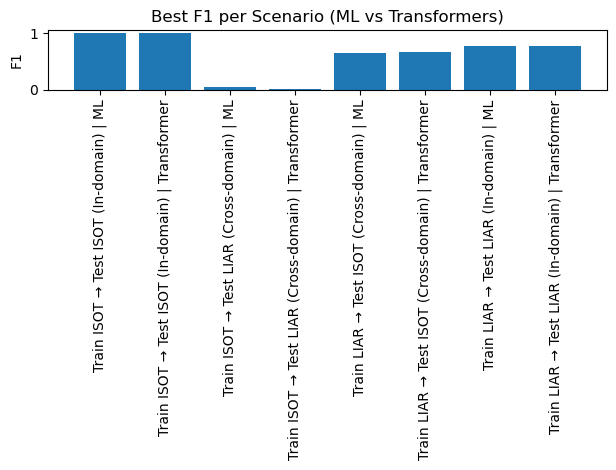

In [26]:
# Simple plots
# Plot 1: - F1 by scenario
plot_df = scenarios.copy()
plot_df = plot_df.sort_values("F1", ascending=False)

plt.figure()
# We'll plot the top 8 rows per scenario is messy; instead plot best model in each family per scenario.
plot_rows = []
for scen in scenarios["Scenario"].unique():
    for fam in ["ML", "Transformer"]:
        sub = scenarios[(scenarios["Scenario"] == scen) & (scenarios["Family"] == fam)]
        if sub.empty:
            continue
        best = sub.sort_values("F1", ascending=False).iloc[0]
        plot_rows.append(best)

plot_best = pd.DataFrame(plot_rows)
plt.bar(range(len(plot_best)), plot_best["F1"].values)
plt.xticks(range(len(plot_best)), plot_best["Scenario"] + " | " + plot_best["Family"], rotation=90)
plt.ylabel("F1")
plt.title("Best F1 per Scenario (ML vs Transformers)")
plt.tight_layout()
plt.savefig("results/figures/best_f1_per_scenario.png", dpi=200)
plt.show()

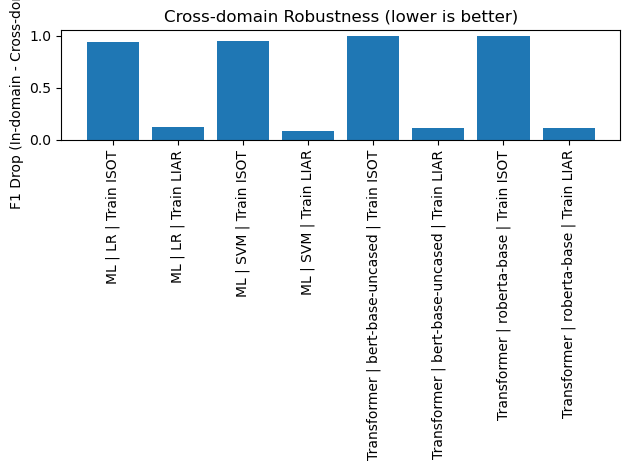

In [27]:
# Plot 2: - F1 drop per model
plt.figure()
plt.bar(range(len(f1_drop_df)), f1_drop_df["F1_Drop"].values)
plt.xticks(range(len(f1_drop_df)),
           f1_drop_df["Family"] + " | " + f1_drop_df["Model"] + " | Train " + f1_drop_df["TrainDomain"],
           rotation=90)
plt.ylabel("F1 Drop (In-domain - Cross-domain)")
plt.title("Cross-domain Robustness (lower is better)")
plt.tight_layout()
plt.savefig("results/figures/f1_drop_by_model.png", dpi=200)
plt.show()

In [28]:
# Print a ready-to-use “Key Findings” summary (for your dissertation)
print("=== Key Findings Summary ===")
print("\nBest model per scenario:")
print(best_by_scenario.to_string(index=False))

print("\nF1 drop summary (robustness):")
print(f1_drop_df.to_string(index=False))

print("\nTransformer vs ML improvement:")
print(improvement_df.to_string(index=False))

=== Key Findings Summary ===

Best model per scenario:
                             Scenario      Family             Model  Accuracy  Precision   Recall       F1
   Train ISOT → Test ISOT (In-domain) Transformer bert-base-uncased  1.000000   1.000000 1.000000 1.000000
Train ISOT → Test LIAR (Cross-domain)          ML                LR  0.371744   0.666667 0.024814 0.047847
Train LIAR → Test ISOT (Cross-domain) Transformer bert-base-uncased  0.501667   0.500835 1.000000 0.667408
   Train LIAR → Test LIAR (In-domain) Transformer      roberta-base  0.636938   0.636867 0.998759 0.777778

F1 drop summary (robustness):
     Family             Model TrainDomain  F1_InDomain  F1_CrossDomain  F1_Drop
         ML                LR        ISOT     0.988970        0.047847 0.941123
         ML                LR        LIAR     0.764615        0.641204 0.123410
         ML               SVM        ISOT     0.994546        0.043165 0.951380
         ML               SVM        LIAR     0.710572     

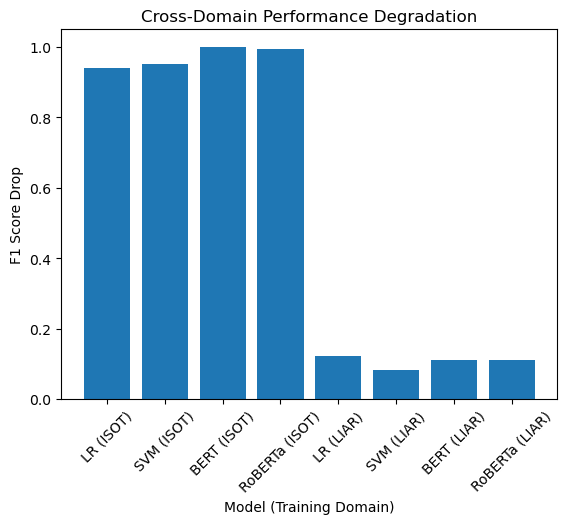

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Model": ["LR (ISOT)", "SVM (ISOT)", "BERT (ISOT)", "RoBERTa (ISOT)",
              "LR (LIAR)", "SVM (LIAR)", "BERT (LIAR)", "RoBERTa (LIAR)"],
    "F1_Drop": [0.9411, 0.9514, 1.0, 0.9951, 0.1234, 0.0830, 0.1100, 0.1111]
}

df = pd.DataFrame(data)

# Create bar chart
plt.figure()
plt.bar(df["Model"], df["F1_Drop"])
plt.xticks(rotation=45)
plt.xlabel("Model (Training Domain)")
plt.ylabel("F1 Score Drop")
plt.title("Cross-Domain Performance Degradation")

# IMPORTANT: Save the figure
plt.savefig("f1_drop_chart.png", bbox_inches='tight', dpi=300)

plt.show()